Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* No ResNet
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 80 blocks (MaxPool2D in each second block)

In [7]:
in_channels = 3
out_channels = 8
size = 64

model_blocks = []

for i in range(80):
    conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
    batch_norm = nn.BatchNorm2d(out_channels)
    model_blocks.extend(
        [conv, batch_norm, nn.ReLU()]
    )
        
    in_channels = out_channels        
    if i%20 == 0:
        out_channels = out_channels*2
        model_blocks.append(nn.MaxPool2d(2,2))
        size = size//2
    

print(f"Final In Channels = {in_channels}")
print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final In Channels = 128
Final Out Channels = 128
Final Shape = 4


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(in_channels * size * size, in_channels),
    nn.ReLU(),
    nn.Linear(in_channels, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment6/",
    save_checkpoints=10,
    print_every=5
    )

In [22]:
history = trainer.fit(200)

Epoch [5/200] | Train Loss: 0.7830 | Val Loss: 0.8306 | Train Acc: 0.6474 | Val Acc: 0.6327 | Train F1: 0.6459 | Val F1: 0.6324
Epoch [10/200] | Train Loss: 0.7867 | Val Loss: 0.8337 | Train Acc: 0.6418 | Val Acc: 0.6504 | Train F1: 0.6415 | Val F1: 0.6487
Epoch [15/200] | Train Loss: 0.7540 | Val Loss: 0.7945 | Train Acc: 0.6659 | Val Acc: 0.6637 | Train F1: 0.6652 | Val F1: 0.6665
Epoch [20/200] | Train Loss: 0.7544 | Val Loss: 0.9265 | Train Acc: 0.6682 | Val Acc: 0.5752 | Train F1: 0.6674 | Val F1: 0.5611
Epoch [25/200] | Train Loss: 0.7391 | Val Loss: 0.8213 | Train Acc: 0.6801 | Val Acc: 0.6549 | Train F1: 0.6797 | Val F1: 0.6547
Epoch [30/200] | Train Loss: 0.7362 | Val Loss: 0.7673 | Train Acc: 0.6810 | Val Acc: 0.6814 | Train F1: 0.6806 | Val F1: 0.6811
Epoch [35/200] | Train Loss: 0.7369 | Val Loss: 0.8222 | Train Acc: 0.6711 | Val Acc: 0.6704 | Train F1: 0.6707 | Val F1: 0.6722
Epoch [40/200] | Train Loss: 0.7124 | Val Loss: 0.8043 | Train Acc: 0.6900 | Val Acc: 0.6814 | Tra

### Save Metrics

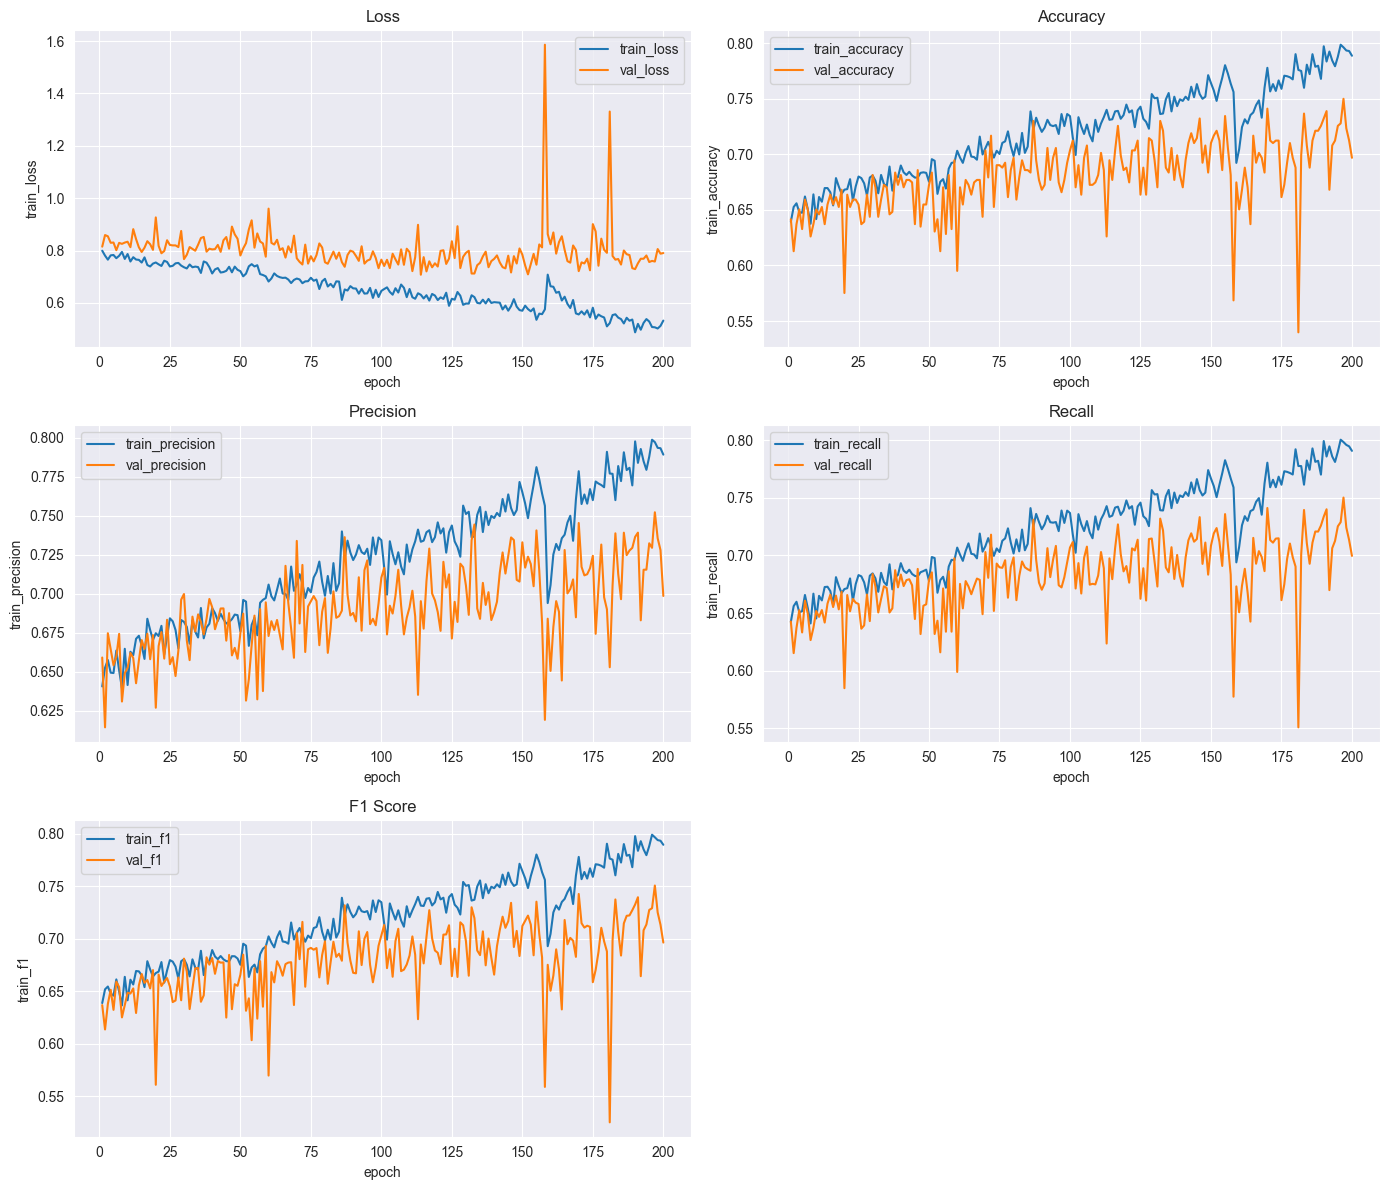

In [23]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment6/tables/training_metrics_400.csv", index=False)

### Training/Validation Trend (100 epochs)
* Training loss steadily decreases across 400 epochs.
* Training accuracy consistently improves from low initial performance to around 80%.
* Validation accuracy improves gradually and reaches approximately 75%.
* Precision, recall, and F1-score increase together, showing improved class discrimination.
* Early epochs show unstable predictions and class imbalance.
* Mid-training epochs show strong feature learning and better class separation.
* Later epochs show slower improvement, indicating convergence.
* Training metrics remain slightly higher than validation metrics, showing mild overfitting but good generalization.
* Validation performance continues improving until the final training stage.
* No major collapse or degradation is observed during training.

The model learns progressively throughout the 400 epochs, moving from weak initial classification ability to strong feature extraction and classification performance. Training and validation metrics improve together, indicating that the model is learning meaningful patterns rather than only memorizing the training data. The small gap between training and validation performance suggests controlled overfitting, and the model appears to approach convergence near the final epochs.
<b>Best Epoch 397</b>

<b>Loss</b>
* Train Loss = 0.506813
* Valid Loss = 0.757981

<b>Training Metrics</b>
* Train Accuracy = 0.796314
* Train Precison = 0.797136
* Train Recall = 0.798307
* Train F1 = 0.796505

<b>Validation Accuracy</b>
* Validation Accuracy = 0.750000
* Validation Precision = 0.752173
* Validation Recall = 0.750179
* Validation F1 = 0.750634

## Use Tester Module to Test Model

Load Model with State Dict

In [25]:
# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment6"
)

Finished testing epoch 1
Finished testing epoch 2
Finished testing epoch 4
Finished testing epoch 5
Finished testing epoch 6
Finished testing epoch 7
Finished testing epoch 8
Finished testing epoch 9
Finished testing epoch 10
Finished testing epoch 12
Finished testing epoch 13
Finished testing epoch 14
Finished testing epoch 15
Finished testing epoch 19
Finished testing epoch 20
Finished testing epoch 30
Finished testing epoch 31
Finished testing epoch 34
Finished testing epoch 38
Finished testing epoch 39
Finished testing epoch 40
Finished testing epoch 41
Finished testing epoch 42
Finished testing epoch 46
Finished testing epoch 47
Finished testing epoch 50
Finished testing epoch 51
Finished testing epoch 53
Finished testing epoch 56
Finished testing epoch 59
Finished testing epoch 60
Finished testing epoch 62
Finished testing epoch 68
Finished testing epoch 70
Finished testing epoch 71
Finished testing epoch 72
Finished testing epoch 74
Finished testing epoch 75
Finished testing epo

### Save Test Metrics

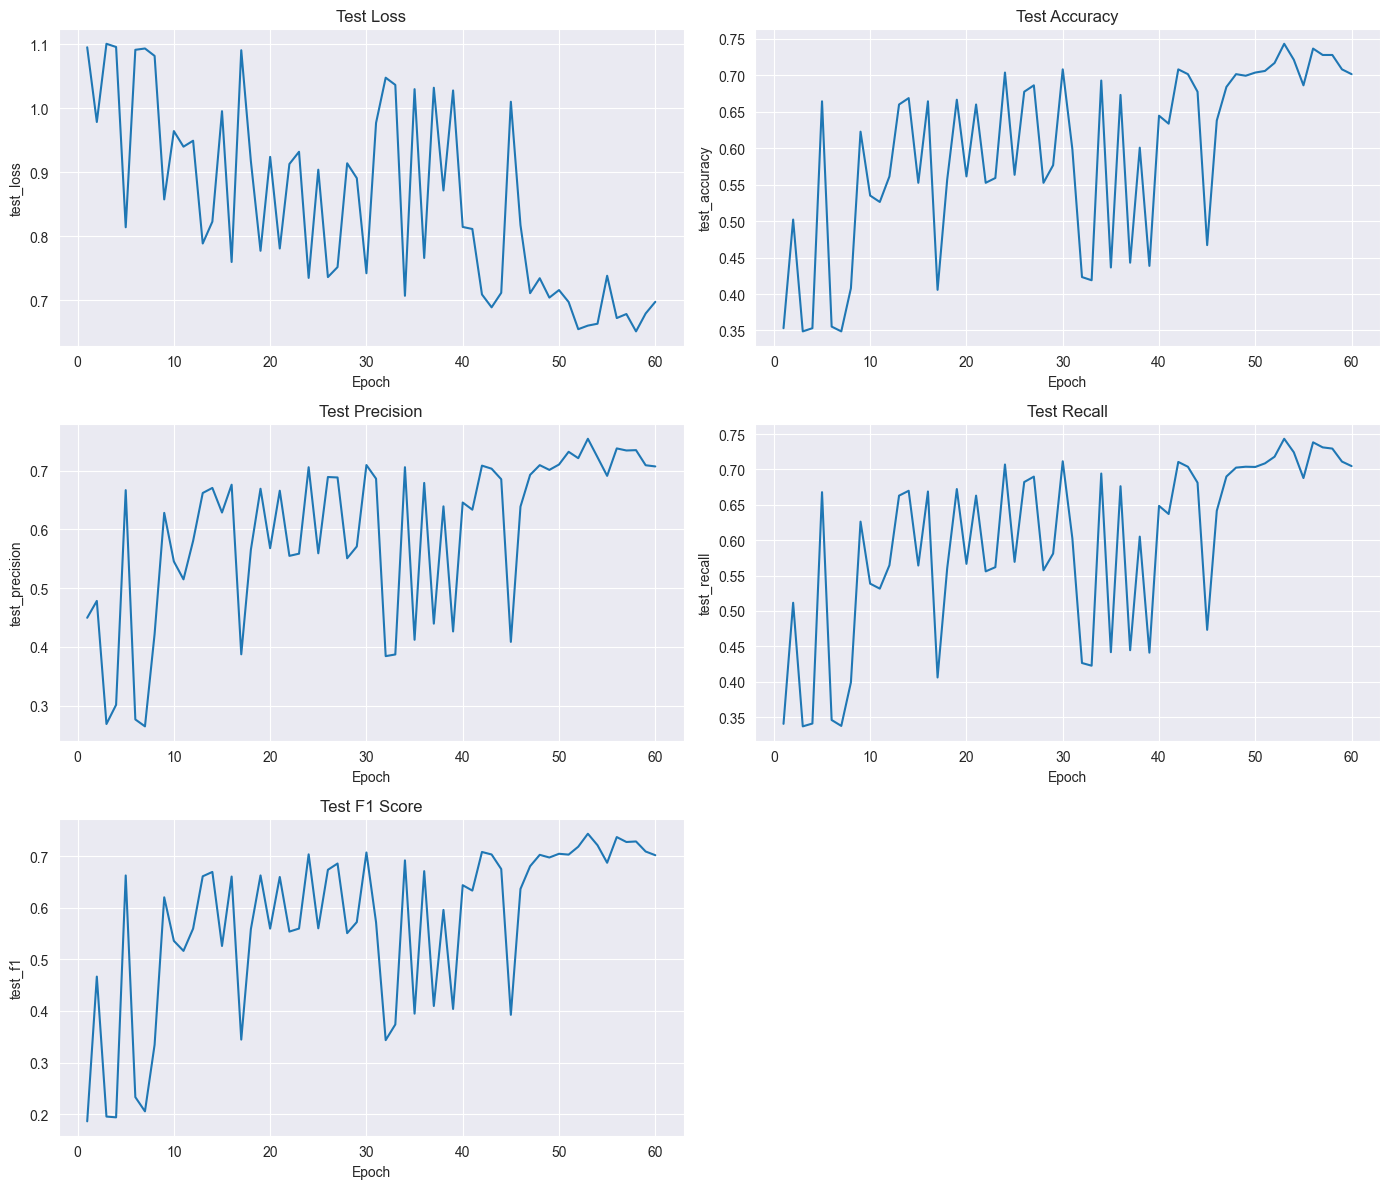

In [26]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment6/tables/test_metrics_400.csv", index=False)

### Test Performance Trend (100 epochs)
* Test loss generally decreases as training progresses, showing improved model confidence.
* Test accuracy increases from around 35% in early epochs to above 70% in later epochs.
* Precision, recall, and F1-score improve together, indicating better classification performance across classes.
* Early test epochs show unstable predictions and weak class separation.
* Around epoch 100–150, the model starts achieving consistent improvement.
* Around epoch 200–260, the model reaches its strongest test performance.
* The highest improvement occurs near the final part of testing, with accuracy stabilizing around 70–74%.
* Test metrics fluctuate between epochs, indicating that some checkpoints generalize better than others.
* The model does not show a major decline after reaching high performance.
* The best checkpoint is not the final epoch, suggesting that saving the best-performing epoch is preferable.

The test results show that the model gradually improves its ability to classify unseen data throughout training. Performance starts near random classification but increases steadily as the model learns useful features. The highest test performance occurs around the later epochs, where accuracy, precision, recall, and F1-score are balanced. The fluctuations between epochs indicate normal variation in generalization, and the best model checkpoint should be selected based on validation/test performance rather than simply using the final epoch.

<b>Best Epoch 97</b>

* Loss = 0.660452
* Accuracy = 0.743421
* Precision = 0.754064
* Recall = 0.743354
* F1-Score = 0.743540